# NOTEBOOK: Support Vector Machine Classifier

 Goal: Implement and evaluate Support Vector Machine Classifier

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data,
    plot_feature_distributions_by_class
)
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import SKLearnSVMClassifier, SKLearnLDA

from src.models.supervised.model_selection import (
    k_fold_cross_validation, 
    plot_cross_validation_results,
    grid_search_cv,
    plot_grid_search_results
)

2025-12-29 23:40:21.862373: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Loading & Exploration

DATA ANALYSIS

Dataset shape: 891 rows × 7 columns

Data types:
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

Missing values:
          Missing_Count  Missing_Percent
Age                 177            19.87
Embarked              2             0.22

Numerical columns (5):
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns (2):
['Sex', 'Embarked']

Numerical features statistics:
           Pclass         Age       SibSp       Parch        Fare
count  891.000000  714.000000  891.000000  891.000000  891.000000
mean     2.308642   29.699118    0.523008    0.381594   32.204208
std      0.836071   14.526497    1.102743    0.806057   49.693429
min      1.000000    0.420000    0.000000    0.000000    0.000000
25%      2.000000   20.125000    0.000000    0.000000    7.910400
50%      3.000000   28.000000    0.000000    0.000000   14.454200
75%      3.000000   38.000000    1

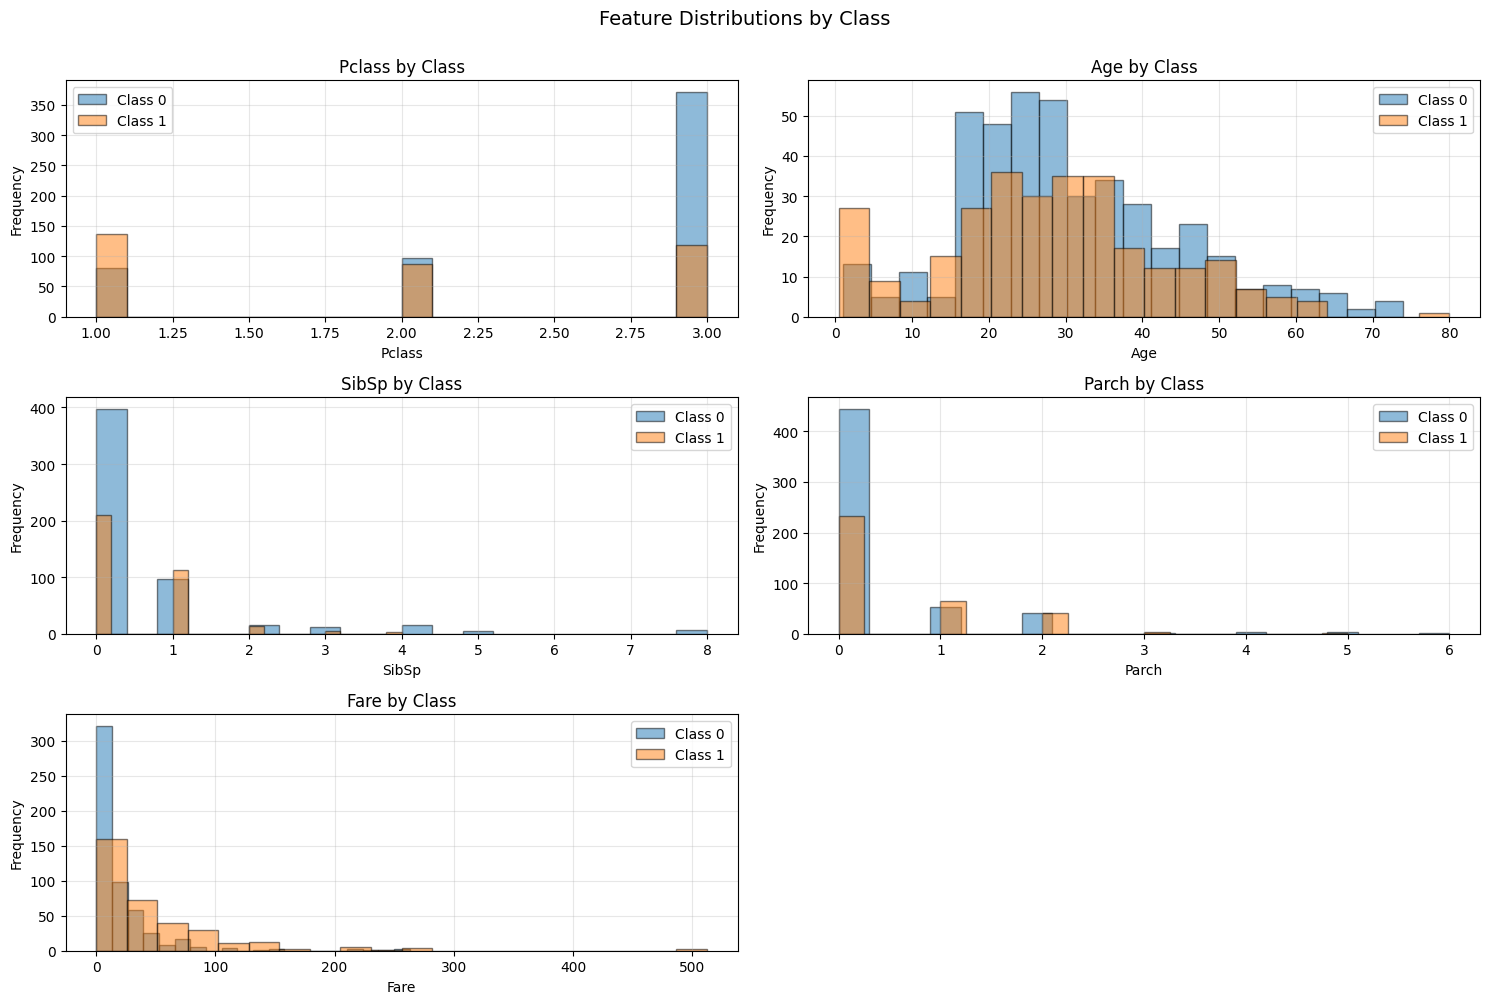

In [2]:
# Load data
# Quick EDA: shape, dtypes, missing values, class distribution
# Feature/target split

X, y = data_loader.load_titanic()

analyze_data(X, show_stats=True)
plot_feature_distributions_by_class(X, y)

## Preprocess Data

In [3]:
# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=True, encode_categorical=True) # Scaling needed for distance-based models
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Training set: {X_train_proc.shape}")
print(f"Test set: {X_test_proc.shape}")
print(f"\nFeature names after preprocessing:")
print(preprocessor.get_feature_names())


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 5 columns
   Nominal categorical: 2 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...
   ✓ Applied most_frequent imputation
   ✓ One-hot encoding 2 nominal columns...
   → Created 5 one-hot features

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 5 features

Final shape: 712 rows × 10 features

Training set: (712, 10)
Test set: (179, 10)

Feature names after preprocessing:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## Baseline Model

In [4]:
model = SKLearnSVMClassifier()
model.fit(X_train_proc, y_train)

baseline_score = model.score(X_test_proc, y_test)
print(f"Baseline accuracy: {baseline_score:.4f}")

Baseline accuracy: 0.8156


## Baseline Evaluation & Diagnostics


BASELINE MODEL EVALUATION
Test Accuracy: 0.8156

Confusion Matrix:


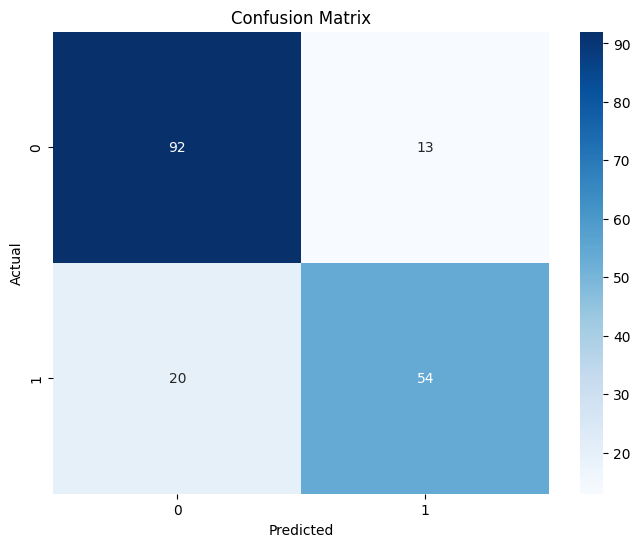

In [5]:
print("\n" + "="*70)
print("BASELINE MODEL EVALUATION")
print("="*70)
print(f"Test Accuracy: {baseline_score:.4f}")

# Confusion matrix (brief)
print("\nConfusion Matrix:")
cm = model.confusion_matrix(X_test_proc, y_test)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## K-Fold Cross-Validation for Robust Evaluation


K-FOLD CROSS-VALIDATION
K-FOLD CROSS-VALIDATION (k=5)
Task: Classification
Scoring: accuracy
Total samples: 712

Fold 1/5: accuracy=0.7972 (train: 569, test: 143)
Fold 2/5: accuracy=0.8811 (train: 569, test: 143)
Fold 3/5: accuracy=0.8521 (train: 570, test: 142)
Fold 4/5: accuracy=0.8028 (train: 570, test: 142)
Fold 5/5: accuracy=0.8169 (train: 570, test: 142)

CROSS-VALIDATION RESULTS
Mean accuracy: 0.8300 ± 0.0319
Min accuracy:  0.7972
Max accuracy:  0.8811


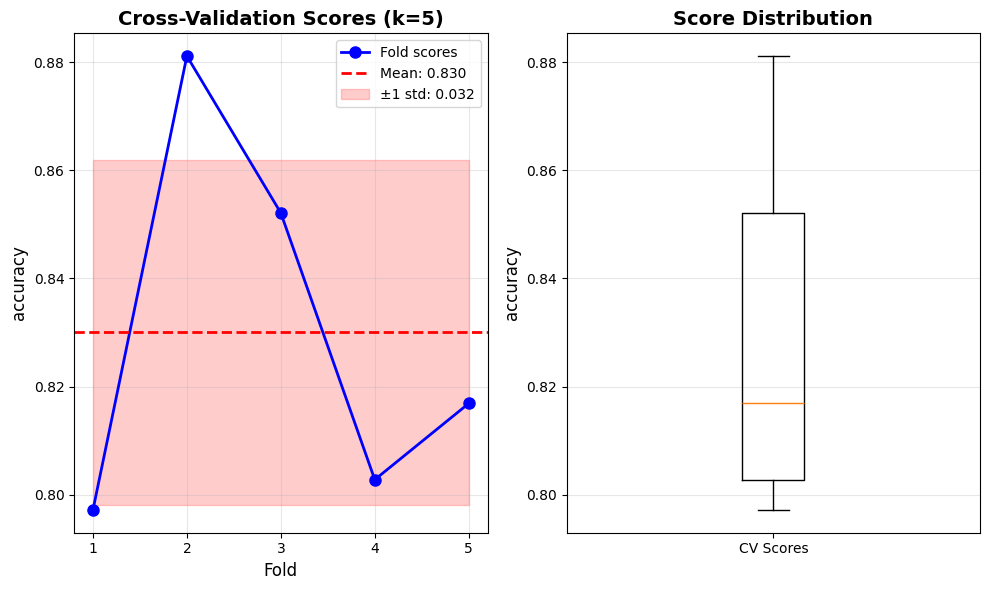

In [6]:
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION")
print("="*70)

# Perform 5-fold cross-validation
cv_baseline = k_fold_cross_validation(
    model=model,  # Use same model as before
    X=X_train_proc,
    y=y_train,
    k=5,
    scoring='accuracy'
)

# Visualize
plot_cross_validation_results(cv_baseline)

## Dimensionality Reduction Visualization


PCA vs LDA VISUALIZATION

⚠️  LDA Auto-adjustment:
   Requested n_components: 2
   Maximum allowed (n_classes - 1): 1
   Using: 1 component(s)

💡 Binary classification detected:
   LDA can only produce 1 component for 2 classes
   This finds the single best line to separate classes

PCA vs LDA VISUALIZATION
Number of classes: 2
PCA type: Linear PCA
PCA components: 2
LDA components: 1

💡 Binary classification: Showing scatter plots + histograms


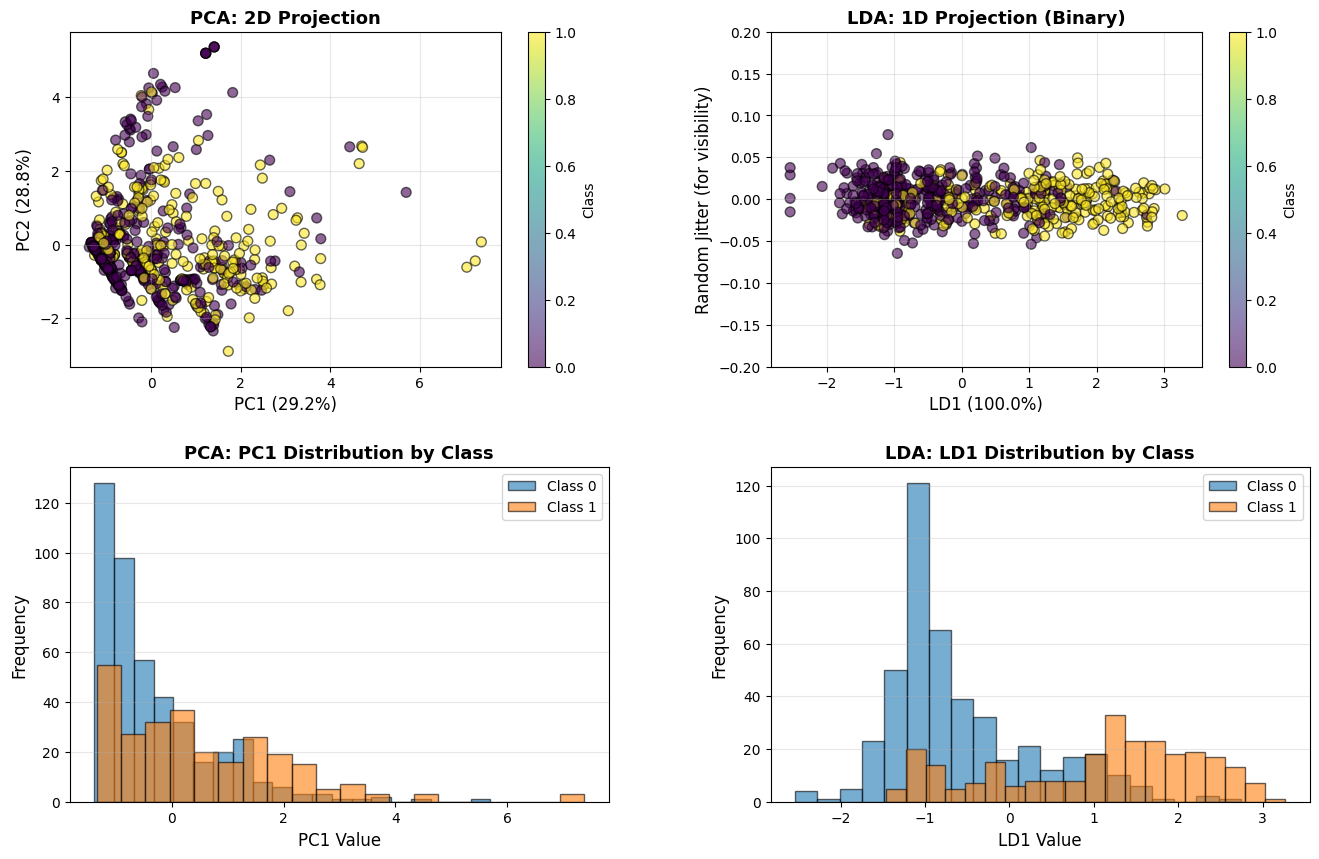


KEY INSIGHTS (Binary Classification)

💡 Why LDA only has 1 component:
   • For 2 classes, LDA can produce at most n_classes - 1 = 1 component
   • This finds the single best line to separate the two classes

💡 Notice in the histograms:
   • LDA (bottom right) shows better separation
   • PCA: Linear variance maximization
   • LDA: Supervised - maximizes class separation using labels

VARIANCE EXPLAINED

PCA: 58.0% total
  PC1: 29.2%
  PC2: 28.8%

LDA: 100.0% total
  LD1: 100.0%


In [7]:
print("\n" + "="*70)
print("PCA vs LDA VISUALIZATION")
print("="*70)

lda = SKLearnLDA(n_components=2)
lda.fit(X_train_proc, y_train)
lda.plot_comparison_with_pca(X_train_proc, y_train)

## Hyper-Parameter Tuning


HYPERPARAMETER TUNING
GRID SEARCH WITH CROSS-VALIDATION
Parameter grid:
  C: [0.1, 1, 10, 100]
  kernel: ['rbf', 'linear', 'poly']
  gamma: ['scale', 'auto', 0.1, 0.01]

Total combinations to test: 48
Cross-validation folds: 5
Total fits: 240

K-FOLD CROSS-VALIDATION (k=5)
Task: Classification
Scoring: accuracy
Total samples: 712

Fold 1/5: accuracy=0.7832 (train: 569, test: 143)
Fold 2/5: accuracy=0.8392 (train: 569, test: 143)
Fold 3/5: accuracy=0.8310 (train: 570, test: 142)
Fold 4/5: accuracy=0.7817 (train: 570, test: 142)
Fold 5/5: accuracy=0.7958 (train: 570, test: 142)

CROSS-VALIDATION RESULTS
Mean accuracy: 0.8062 ± 0.0242
Min accuracy:  0.7817
Max accuracy:  0.8392
[1/48] {'C': 0.1, 'kernel': 'rbf', 'gamma': 'scale', 'random_state': 42}
  → accuracy: 0.8062 ± 0.0242

K-FOLD CROSS-VALIDATION (k=5)
Task: Classification
Scoring: accuracy
Total samples: 712

Fold 1/5: accuracy=0.7832 (train: 569, test: 143)
Fold 2/5: accuracy=0.8322 (train: 569, test: 143)
Fold 3/5: accuracy=0.8

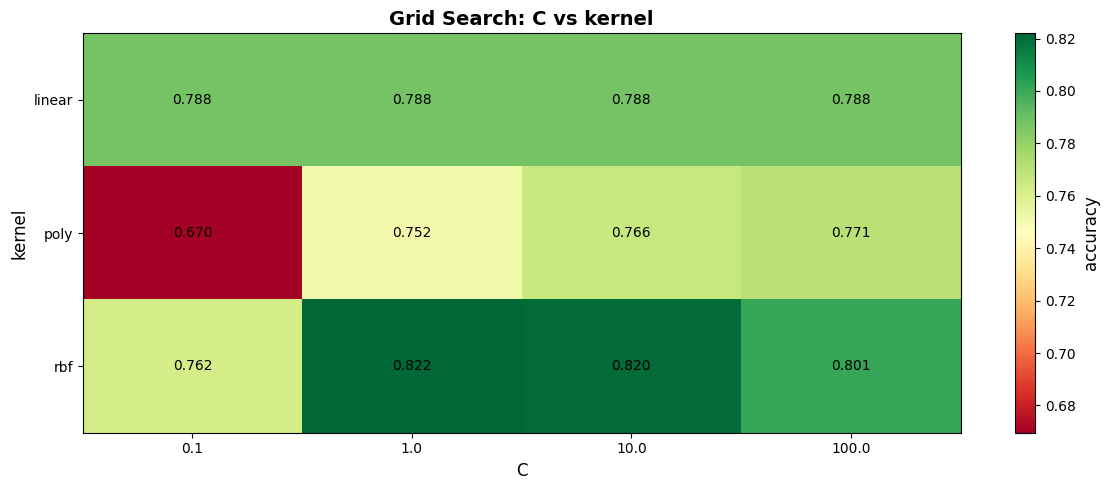


✓ Best parameters: {'C': 100, 'kernel': 'rbf', 'gamma': 0.01, 'random_state': 42}
✓ Best CV score: 0.8314


In [ ]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid based on model
param_grid = {
    # SVM
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

grid_results = grid_search_cv(
    model_class=SKLearnSVMClassifier,
    param_grid=param_grid,
    X=X_train_proc,
    y=y_train,
    cv=5,
    verbose=True
)

# Visualize grid search results (if 2 parameters)
if len(param_grid) >= 2:
    param_names = list(param_grid.keys())
    plot_grid_search_results(grid_results, param_names[0], param_names[1])

print(f"\n✓ Best parameters: {grid_results['best_params']}")
print(f"✓ Best CV score: {grid_results['best_score']:.4f}")

## Final Model Evaluation


FINAL MODEL EVALUATION
Test Accuracy: 0.8268

Confusion Matrix:


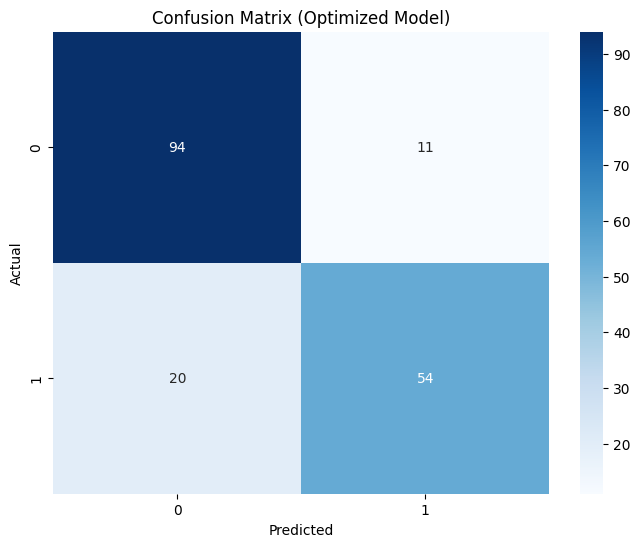


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       105
           1       0.83      0.73      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.82       179



In [9]:
best_model = grid_results['best_model']

final_score = best_model.score(X_test_proc, y_test)

print("\n" + "="*70)
print("FINAL MODEL EVALUATION")
print("="*70)
print(f"Test Accuracy: {final_score:.4f}")

print("\nConfusion Matrix:")
cm_final = best_model.confusion_matrix(X_test_proc, y_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Optimized Model)')
plt.show()

print("\nClassification Report:")
print(best_model.classification_report(X_test_proc, y_test))

## Model Comparison


MODEL COMPARISON
              Model  Accuracy       Std
0   Baseline (test)  0.815642       NaN
1     Baseline (CV)  0.830031  0.031901
2    Optimized (CV)  0.831449       NaN
3  Optimized (test)  0.826816       NaN


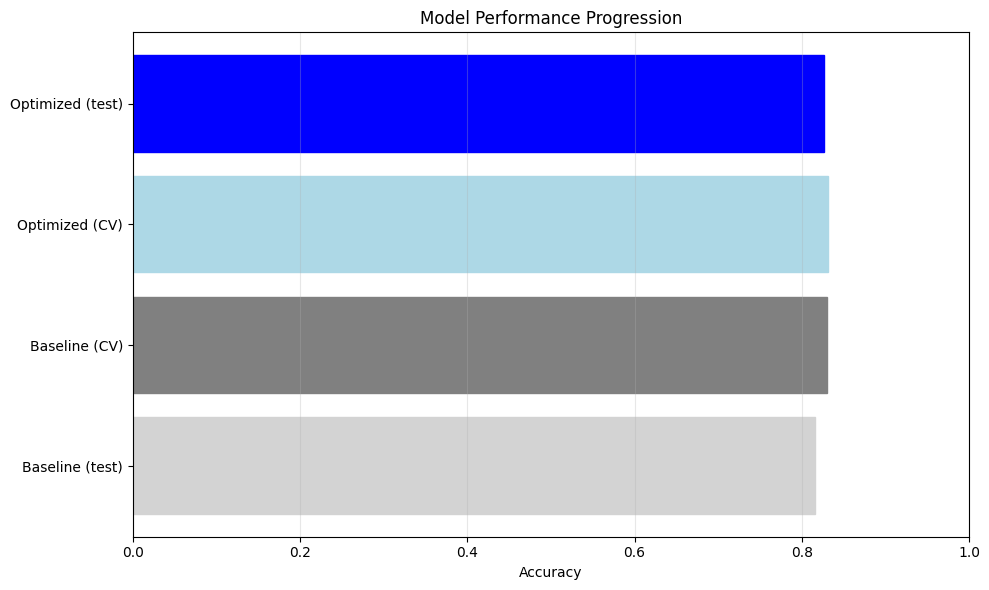


💡 Improvement from tuning: 1.12%


In [10]:
comparison_df = pd.DataFrame({
    'Model': ['Baseline (test)', 'Baseline (CV)', 'Optimized (CV)', 'Optimized (test)'],
    'Accuracy': [
        baseline_score,
        cv_baseline['mean'],
        grid_results['best_score'],
        final_score
    ],
    'Std': [None, cv_baseline['std'], None, None]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.barh(comparison_df['Model'], comparison_df['Accuracy'])
bars[0].set_color('lightgray')
bars[1].set_color('gray')
bars[2].set_color('lightblue')
bars[3].set_color('blue')
plt.xlabel('Accuracy')
plt.title('Model Performance Progression')
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n💡 Improvement from tuning: {(final_score - baseline_score)*100:.2f}%")

## Key Insights & Summary

In [11]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"\n✓ Baseline accuracy: {baseline_score:.4f}")
print(f"✓ Optimized accuracy: {final_score:.4f}")
print(f"✓ Improvement: {(final_score - baseline_score)*100:.2f}%")
print(f"\n✓ Best hyperparameters found:")
for param, value in grid_results['best_params'].items():
    print(f"   • {param}: {value}")


KEY INSIGHTS

✓ Baseline accuracy: 0.8156
✓ Optimized accuracy: 0.8268
✓ Improvement: 1.12%

✓ Best hyperparameters found:
   • C: 100
   • kernel: rbf
   • gamma: 0.01
   • random_state: 42
